# LinkTo-Anime 姿态关键点可视化

本 Notebook 共三个部分：
1. **探索数据结构** — 打印 JSON 中所有骨骼名称 & 数据格式
2. **全量关键点预览** — 在渲染帧上画出所有 bone
3. **标准格式转换 + 预览** — 转为 COCO-17 / Halpe-26 / 自定义动画19点

In [ ]:
import json, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path


# 数据目录结构遵循link-to-anime 项目文件中的任意一个 "**model"文件夹。
DATA_ROOT = Path("./68 model")          # notebook 所在目录即数据根目录
CLIP_ID   = "01"               # 用哪个 clip 做演示，例如 '01' '04'
FRAME_IDX = 0                  # 用第几帧（0-based）

clip_dir  = DATA_ROOT / f"{CLIP_ID} visual_view"
json_pix  = clip_dir / f"{CLIP_ID}_9 bone_coordinates_pixels.json"
json_img  = clip_dir / f"{CLIP_ID}_8 bone_coordinates_image.json"
render_dir= clip_dir / f"{CLIP_ID}_1 Rendering"

print(f"Clip dir : {clip_dir}")
print(f"Pixel JSON: {json_pix}  exists={json_pix.exists()}")
print(f"Image JSON: {json_img}  exists={json_img.exists()}")

Clip dir : 68 model/01 visual_view
Pixel JSON: 68 model/01 visual_view/01_9 bone_coordinates_pixels.json  exists=True
Image JSON: 68 model/01 visual_view/01_8 bone_coordinates_image.json  exists=True


## 第一部分 — 探索 JSON 数据结构

In [4]:
with open(json_pix) as f:
    raw = json.load(f)

print("JSON 顶层 type:", type(raw))
if isinstance(raw, dict):
    print("顶层 keys sample:", list(raw.keys())[:5])
    # 尝试找到第一帧
    first_key = list(raw.keys())[0]
    first_val = raw[first_key]
    print(f"\n第一个 key: {first_key!r}")
    print("  value type:", type(first_val))
    if isinstance(first_val, dict):
        bone_names = list(first_val.keys())
        print(f"  骨骼数量: {len(bone_names)}")
        print("  骨骼名称:")
        for i, name in enumerate(bone_names):
            print(f"    [{i:03d}] {name}  → {first_val[name]}")
    elif isinstance(first_val, list):
        print("  列表长度:", len(first_val))
        print("  第一条:", first_val[0])
elif isinstance(raw, list):
    print("列表长度:", len(raw))
    print("第一条 type:", type(raw[0]))
    if isinstance(raw[0], dict):
        print("第一条 keys:", list(raw[0].keys())[:10])

JSON 顶层 type: <class 'dict'>
顶层 keys sample: ['1', '2', '3', '4', '5']

第一个 key: '1'
  value type: <class 'dict'>
  骨骼数量: 65
  骨骼名称:
    [000] mixamorig:Hips  → {'x': 1323.811339260895, 'y': 1202.4335864545471, 'z': 0}
    [001] mixamorig:Spine  → {'x': 1323.409009976397, 'y': 1119.3550097142381, 'z': 0}
    [002] mixamorig:Spine1  → {'x': 1319.3719414264951, 'y': 1022.2344482724927, 'z': 0}
    [003] mixamorig:Spine2  → {'x': 1312.2124161969236, 'y': 911.1976361726298, 'z': 0}
    [004] mixamorig:Neck  → {'x': 1301.4043689526038, 'y': 785.9025245588372, 'z': 0}
    [005] mixamorig:Head  → {'x': 1301.894592120056, 'y': 703.3116464641229, 'z': 0}
    [006] mixamorig:HeadTop_End  → {'x': 1325.570990765041, 'y': 409.88889467918295, 'z': 0}
    [007] mixamorig:LeftShoulder  → {'x': 1345.3294337120371, 'y': 811.8306587656574, 'z': 0}
    [008] mixamorig:LeftArm  → {'x': 1420.1843804738492, 'y': 878.496356078842, 'z': 0}
    [009] mixamorig:LeftForeArm  → {'x': 1408.1649115605799, 'y': 1104.

In [5]:
# ─────────────────────────────────────────────
# 通用解析器：把各种可能的 JSON 结构统一成
# frames_data[frame_idx] = {bone_name: (x, y), ...}
# ─────────────────────────────────────────────

def parse_bone_json(path):
    """返回 list of dict: [{bone_name: (x,y)}, ...] 按帧顺序"""
    with open(path) as f:
        raw = json.load(f)

    def to_xy(v):
        """把各种坐标格式统一为 (x, y)"""
        if isinstance(v, (list, tuple)):
            return (float(v[0]), float(v[1]))
        if isinstance(v, dict):
            if 'x' in v and 'y' in v:
                return (float(v['x']), float(v['y']))
            vals = list(v.values())
            return (float(vals[0]), float(vals[1]))
        return None

    frames = []

    # Case A: {frame_key: {bone_name: coord, ...}, ...}
    if isinstance(raw, dict):
        for key in sorted(raw.keys()):
            frame_val = raw[key]
            if isinstance(frame_val, dict):
                frame_dict = {}
                for bone, coord in frame_val.items():
                    xy = to_xy(coord)
                    if xy:
                        frame_dict[bone] = xy
                frames.append(frame_dict)
            elif isinstance(frame_val, list):
                # {frame_key: [{name:..., x:..., y:...}, ...]}
                frame_dict = {}
                for item in frame_val:
                    if isinstance(item, dict):
                        name = item.get('name') or item.get('bone') or item.get('joint')
                        if name:
                            xy = to_xy(item)
                            if xy:
                                frame_dict[name] = xy
                frames.append(frame_dict)

    # Case B: [{bone_name: coord, ...}, ...]
    elif isinstance(raw, list):
        for frame_val in raw:
            if isinstance(frame_val, dict):
                frame_dict = {}
                for bone, coord in frame_val.items():
                    if bone in ('frame', 'index', 'id'):
                        continue
                    xy = to_xy(coord)
                    if xy:
                        frame_dict[bone] = xy
                frames.append(frame_dict)

    return frames

frames_data = parse_bone_json(json_pix)
print(f"总帧数: {len(frames_data)}")
if frames_data:
    sample = frames_data[0]
    ALL_BONES = list(sample.keys())
    print(f"骨骼数量: {len(ALL_BONES)}")
    print("所有骨骼名称:")
    for i, b in enumerate(ALL_BONES):
        print(f"  [{i:03d}] {b}  {sample[b]}")

总帧数: 72
骨骼数量: 65
所有骨骼名称:
  [000] mixamorig:Hips  (1323.811339260895, 1202.4335864545471)
  [001] mixamorig:Spine  (1323.409009976397, 1119.3550097142381)
  [002] mixamorig:Spine1  (1319.3719414264951, 1022.2344482724927)
  [003] mixamorig:Spine2  (1312.2124161969236, 911.1976361726298)
  [004] mixamorig:Neck  (1301.4043689526038, 785.9025245588372)
  [005] mixamorig:Head  (1301.894592120056, 703.3116464641229)
  [006] mixamorig:HeadTop_End  (1325.570990765041, 409.88889467918295)
  [007] mixamorig:LeftShoulder  (1345.3294337120371, 811.8306587656574)
  [008] mixamorig:LeftArm  (1420.1843804738492, 878.496356078842)
  [009] mixamorig:LeftForeArm  (1408.1649115605799, 1104.2914389150417)
  [010] mixamorig:LeftHand  (1122.3798771471038, 1015.7752259626631)
  [011] mixamorig:LeftHandThumb1  (1121.3728868076903, 969.6268497885528)
  [012] mixamorig:LeftHandThumb2  (1116.3556257436371, 936.4732644986739)
  [013] mixamorig:LeftHandThumb3  (1100.1648702869613, 917.0416982234406)
  [014] mixamo

In [6]:
# 获取渲染帧路径列表
img_exts = ['*.png','*.jpg','*.jpeg','*.PNG','*.JPG']
img_files = []
for ext in img_exts:
    img_files += sorted(glob.glob(str(render_dir / ext)))
img_files = sorted(set(img_files))
print(f"渲染帧数量: {len(img_files)}")
if img_files:
    print("第一帧:", img_files[0])

渲染帧数量: 72
第一帧: 68 model/01 visual_view/01_1 Rendering/0001_1.png


## 第二部分 — 全量关键点预览

In [7]:
# 颜色方案：按身体部位分色
PART_COLORS = {
    'head'    : '#FF6B6B',
    'spine'   : '#FFD93D',
    'left_arm': '#6BCB77',
    'right_arm':'#4D96FF',
    'left_leg': '#C77DFF',
    'right_leg':'#FF9F1C',
    'face'    : '#FF6BCD',
    'hair'    : '#A8DADC',
    'other'   : '#B0B0B0',
}

def classify_bone(name):
    n = name.lower()
    if any(x in n for x in ['eye','jaw','mouth','lip','brow','nose','cheek','ear','face']):
        return 'face'
    if any(x in n for x in ['hair','ahoge','bang','ponytail','braid','twintail']):
        return 'hair'
    if any(x in n for x in ['head','neck']):
        return 'head'
    if any(x in n for x in ['spine','hips','chest','shoulder_c','pelvis']):
        return 'spine'
    if any(x in n for x in ['left']) and any(x in n for x in ['arm','elbow','forearm','hand','shoulder','wrist','finger','thumb','index','middle','ring','pinky']):
        return 'left_arm'
    if any(x in n for x in ['right']) and any(x in n for x in ['arm','elbow','forearm','hand','shoulder','wrist','finger','thumb','index','middle','ring','pinky']):
        return 'right_arm'
    if any(x in n for x in ['left']) and any(x in n for x in ['leg','knee','foot','toe','upleg','thigh','calf']):
        return 'left_leg'
    if any(x in n for x in ['right']) and any(x in n for x in ['leg','knee','foot','toe','upleg','thigh','calf']):
        return 'right_leg'
    return 'other'

def get_bone_color(name):
    return PART_COLORS[classify_bone(name)]

print("颜色分类方案已加载")

颜色分类方案已加载


/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 39592 (\N{CJK UNIFIED IDEOGRAPH-9AA8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 39612 (\N{CJK UNIFIED IDEOGRAPH-9ABC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 38190 (\N{CJK UNIFIED IDEOGRAPH-952E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/3256606654.py:32: UserWarning: Glyph 28857 (\N{CJK UNIFIED I

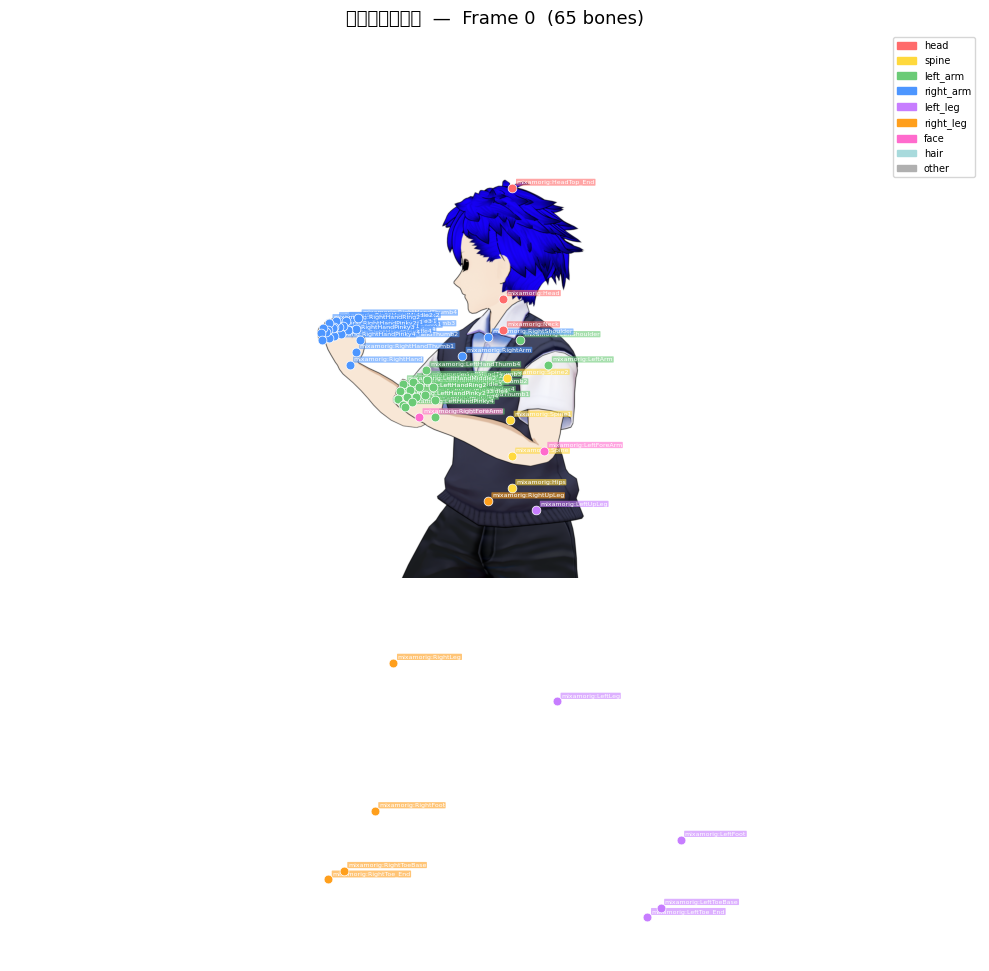

In [9]:
def draw_all_bones(frame_idx=0, figsize=(10,16), annotate=True, point_size=40):
    """在渲染帧上画出全部骨骼关键点"""
    if not frames_data:
        print("无帧数据")
        return
    if not img_files:
        print("无渲染帧图像")
        return

    frame_idx = min(frame_idx, len(frames_data)-1, len(img_files)-1)
    frame_kps = frames_data[frame_idx]
    img = Image.open(img_files[frame_idx]).convert('RGB')
    W, H = img.size

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img)
    ax.set_title(f"全量骨骼关键点  —  Frame {frame_idx}  ({len(frame_kps)} bones)", fontsize=13)

    for bone_name, (x, y) in frame_kps.items():
        color = get_bone_color(bone_name)
        ax.scatter(x, y, s=point_size, c=color, zorder=5, linewidths=0.5, edgecolors='white')
        if annotate:
            ax.annotate(bone_name, (x, y),
                        fontsize=4.5, color='white',
                        xytext=(3, 3), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.1', fc=color, alpha=0.6, lw=0))

    # 图例
    legend_items = [mpatches.Patch(color=v, label=k) for k, v in PART_COLORS.items()]
    ax.legend(handles=legend_items, loc='upper right', fontsize=7, framealpha=0.8)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 预览第 FRAME_IDX 帧
draw_all_bones(frame_idx=FRAME_IDX)

/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 39592 (\N{CJK UNIFIED IDEOGRAPH-9AA8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 39612 (\N{CJK UNIFIED IDEOGRAPH-9ABC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/2462168884.py:21: UserWarning: Glyph 39044 (\N{CJK UNIFIED I

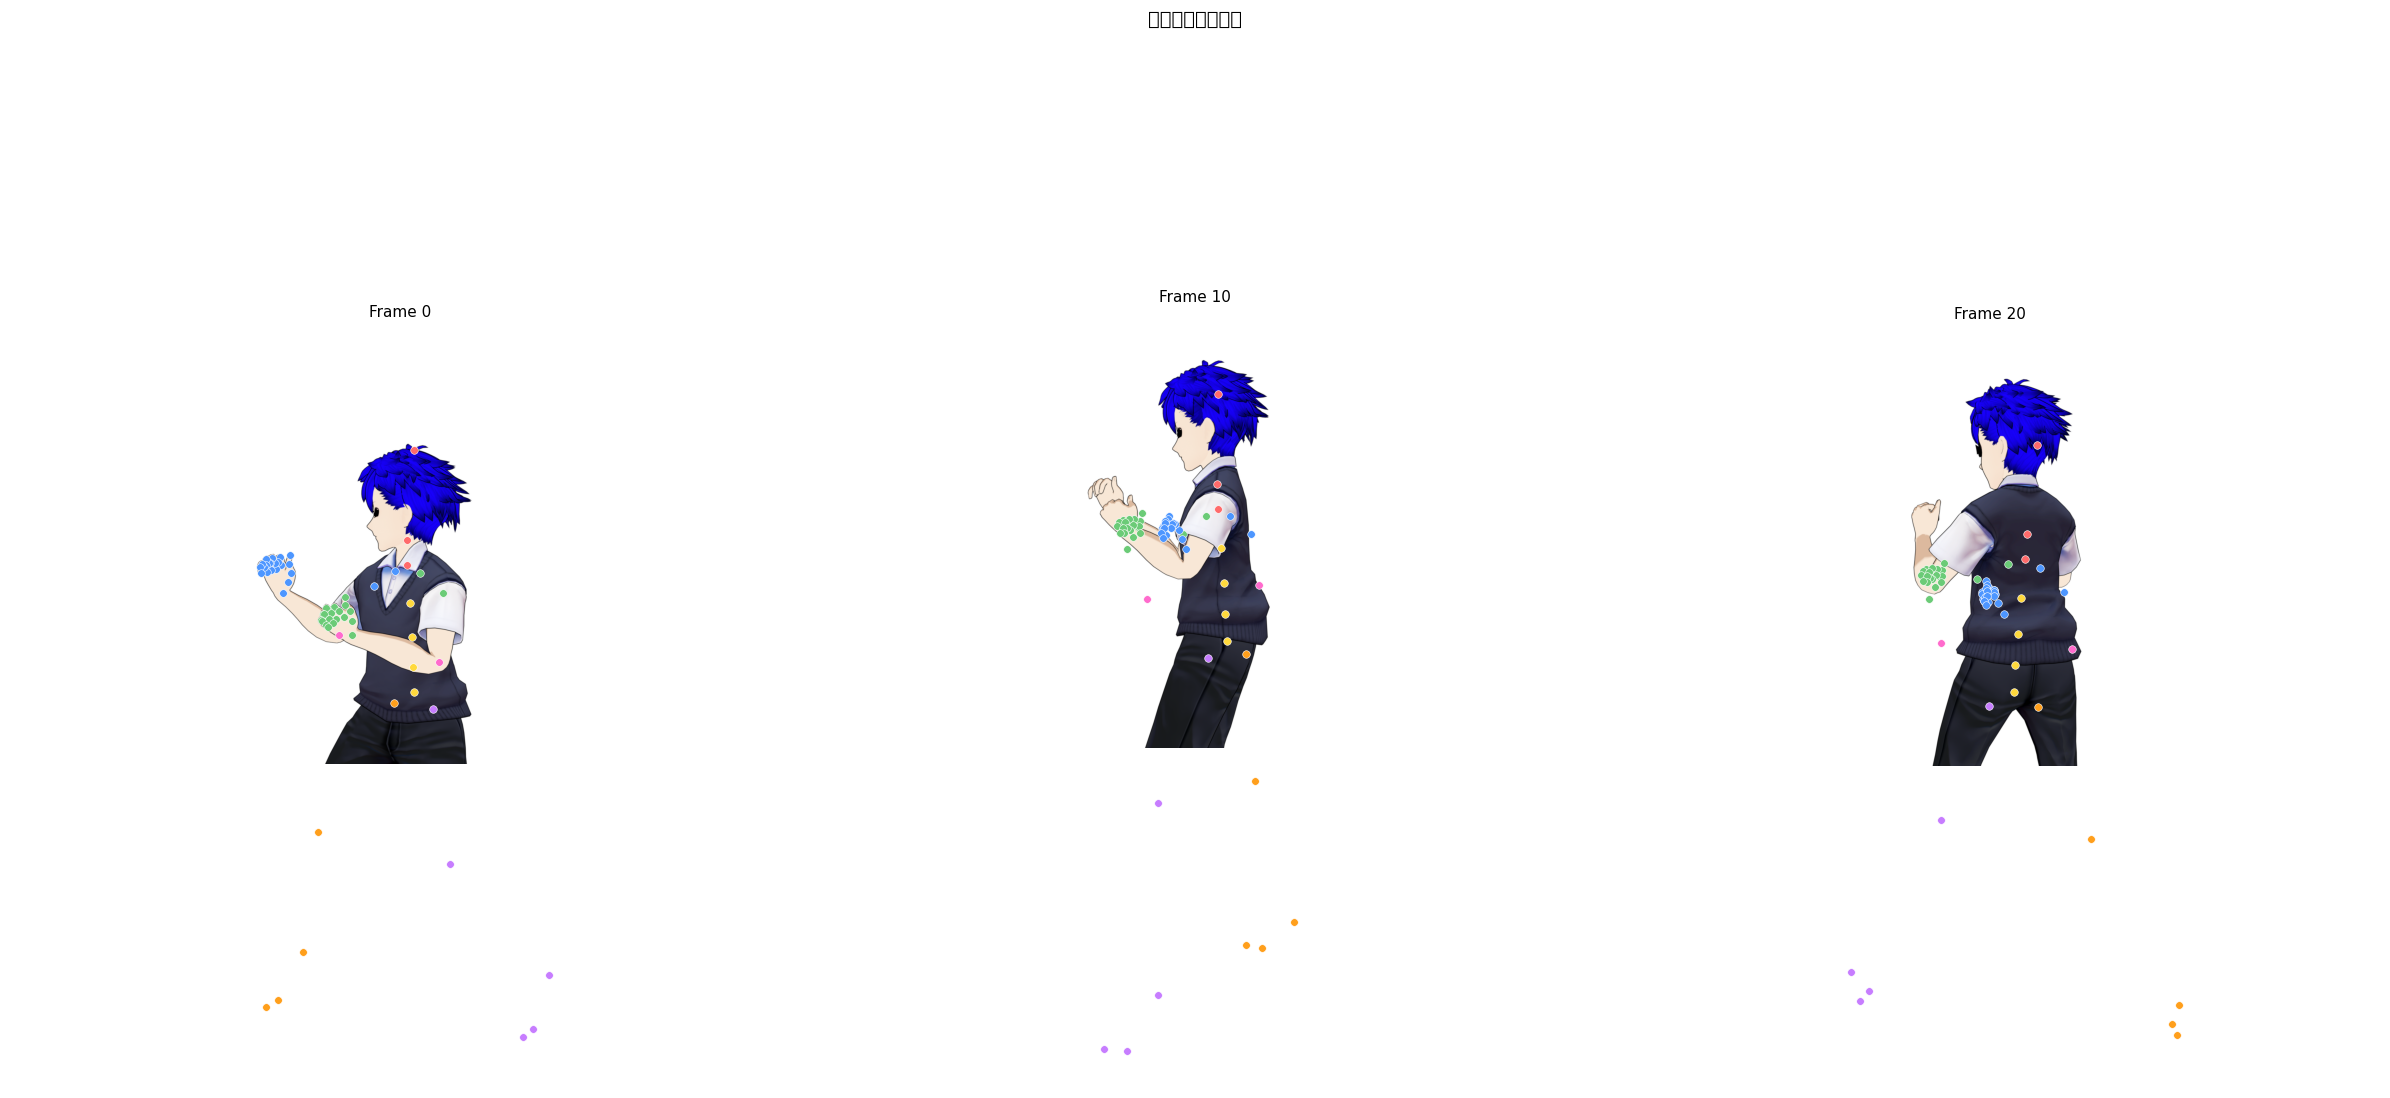

In [10]:
# 多帧对比（可选，默认展示第 0/10/20 帧）
PREVIEW_FRAMES = [0, 10, 20]

n = len(PREVIEW_FRAMES)
fig, axes = plt.subplots(1, n, figsize=(8*n, 14))
if n == 1:
    axes = [axes]

for ax, fidx in zip(axes, PREVIEW_FRAMES):
    fidx = min(fidx, len(frames_data)-1, len(img_files)-1)
    frame_kps = frames_data[fidx]
    img = Image.open(img_files[fidx]).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"Frame {fidx}", fontsize=11)
    for bone_name, (x, y) in frame_kps.items():
        ax.scatter(x, y, s=30, c=get_bone_color(bone_name), zorder=5,
                   linewidths=0.4, edgecolors='white')
    ax.axis('off')

plt.suptitle("多帧全量骨骼预览", fontsize=14)
plt.tight_layout()
plt.show()

## 第三部分 — 转换为标准格式并预览

提供三种格式：
- **COCO-17**：标准17关键点
- **Halpe-26**：含手腕/脚踝/面部关键点
- **AnimePose-19**：本项目推荐动画专用（含双眼）

In [11]:
# ─────────────────────────────────────────────────────────────────
# Mixamo → 标准格式映射表
# 每个 entry: (标准名称, [候选Mixamo骨骼名列表（优先级从高到低）])
# 脚本会按顺序找第一个存在于当前帧的关键点
# ─────────────────────────────────────────────────────────────────

# ── COCO-17 ──────────────────────────────────────────────────────
COCO17_MAP = [
    # (coco_name,  [mixamo candidates...])
    ("nose",            ["Head", "head"]),
    ("left_eye",        ["LeftEye", "Eye_L", "eye_L", "mixamorig:LeftEye"]),
    ("right_eye",       ["RightEye", "Eye_R", "eye_R", "mixamorig:RightEye"]),
    ("left_ear",        ["LeftEar", "Ear_L", "mixamorig:LeftEar"]),
    ("right_ear",       ["RightEar", "Ear_R", "mixamorig:RightEar"]),
    ("left_shoulder",   ["LeftArm", "mixamorig:LeftArm", "LeftShoulder", "mixamorig:LeftShoulder"]),
    ("right_shoulder",  ["RightArm", "mixamorig:RightArm", "RightShoulder", "mixamorig:RightShoulder"]),
    ("left_elbow",      ["LeftForeArm", "mixamorig:LeftForeArm", "LeftElbow"]),
    ("right_elbow",     ["RightForeArm", "mixamorig:RightForeArm", "RightElbow"]),
    ("left_wrist",      ["LeftHand", "mixamorig:LeftHand", "LeftWrist"]),
    ("right_wrist",     ["RightHand", "mixamorig:RightHand", "RightWrist"]),
    ("left_hip",        ["LeftUpLeg", "mixamorig:LeftUpLeg", "LeftHip"]),
    ("right_hip",       ["RightUpLeg", "mixamorig:RightUpLeg", "RightHip"]),
    ("left_knee",       ["LeftLeg", "mixamorig:LeftLeg", "LeftKnee"]),
    ("right_knee",      ["RightLeg", "mixamorig:RightLeg", "RightKnee"]),
    ("left_ankle",      ["LeftFoot", "mixamorig:LeftFoot", "LeftAnkle"]),
    ("right_ankle",     ["RightFoot", "mixamorig:RightFoot", "RightAnkle"]),
]

# ── Halpe-26 ─────────────────────────────────────────────────────
HALPE26_MAP = COCO17_MAP + [
    ("head_top",        ["Head", "head"]),
    ("neck",            ["Neck", "mixamorig:Neck", "Neck1"]),
    ("hip_center",      ["Hips", "mixamorig:Hips", "pelvis"]),
    ("left_big_toe",    ["LeftToeBase", "mixamorig:LeftToeBase"]),
    ("right_big_toe",   ["RightToeBase", "mixamorig:RightToeBase"]),
    ("left_small_toe",  ["LeftToeBase", "mixamorig:LeftToeBase"]),
    ("right_small_toe", ["RightToeBase", "mixamorig:RightToeBase"]),
    ("left_heel",       ["LeftFoot", "mixamorig:LeftFoot"]),
    ("right_heel",      ["RightFoot", "mixamorig:RightFoot"]),
]

# ── AnimePose-19（动画专用，含双眼，无耳鼻） ─────────────────────
ANIME19_MAP = [
    ("head",            ["Head", "mixamorig:Head", "head"]),
    ("left_eye",        ["LeftEye", "Eye_L", "eye_L"]),
    ("right_eye",       ["RightEye", "Eye_R", "eye_R"]),
    ("neck",            ["Neck", "mixamorig:Neck", "Neck1"]),
    ("left_shoulder",   ["LeftArm", "mixamorig:LeftArm", "LeftShoulder"]),
    ("right_shoulder",  ["RightArm", "mixamorig:RightArm", "RightShoulder"]),
    ("left_elbow",      ["LeftForeArm", "mixamorig:LeftForeArm"]),
    ("right_elbow",     ["RightForeArm", "mixamorig:RightForeArm"]),
    ("left_wrist",      ["LeftHand", "mixamorig:LeftHand"]),
    ("right_wrist",     ["RightHand", "mixamorig:RightHand"]),
    ("spine",           ["Spine2", "mixamorig:Spine2", "Chest", "Spine1", "Spine", "mixamorig:Spine"]),
    ("hip_center",      ["Hips", "mixamorig:Hips", "pelvis"]),
    ("left_hip",        ["LeftUpLeg", "mixamorig:LeftUpLeg"]),
    ("right_hip",       ["RightUpLeg", "mixamorig:RightUpLeg"]),
    ("left_knee",       ["LeftLeg", "mixamorig:LeftLeg"]),
    ("right_knee",      ["RightLeg", "mixamorig:RightLeg"]),
    ("left_ankle",      ["LeftFoot", "mixamorig:LeftFoot"]),
    ("right_ankle",     ["RightFoot", "mixamorig:RightFoot"]),
    ("left_toe",        ["LeftToeBase", "mixamorig:LeftToeBase"]),
]

FORMAT_MAPS = {
    'COCO-17':     COCO17_MAP,
    'Halpe-26':    HALPE26_MAP,
    'AnimePose-19':ANIME19_MAP,
}

print("格式映射表加载完毕")

格式映射表加载完毕


In [12]:
def convert_frame(frame_kps: dict, fmt_map: list, verbose=False):
    """
    把一帧的骨骼字典按格式映射表转换。
    返回 {std_name: (x,y) or None}
    """
    result = {}
    bone_keys_lower = {k.lower(): k for k in frame_kps}
    for std_name, candidates in fmt_map:
        found = None
        for cand in candidates:
            if cand in frame_kps:
                found = frame_kps[cand]
                break
            if cand.lower() in bone_keys_lower:
                found = frame_kps[bone_keys_lower[cand.lower()]]
                break
        if verbose and found is None:
            print(f"  [MISS] {std_name}  (tried: {candidates})")
        result[std_name] = found
    return result

# ── 打印匹配情况（用第0帧测试）──────────────────────────────────
print("="*60)
for fmt_name, fmt_map in FORMAT_MAPS.items():
    converted = convert_frame(frames_data[0], fmt_map, verbose=False)
    hit  = sum(1 for v in converted.values() if v is not None)
    total = len(converted)
    print(f"\n【{fmt_name}】  匹配 {hit}/{total} 个关键点")
    for k, v in converted.items():
        status = f"{v[0]:.1f}, {v[1]:.1f}" if v else "未找到"
        print(f"  {'✓' if v else '✗'}  {k:<20}  {status}")


【COCO-17】  匹配 12/17 个关键点
  ✗  nose                  未找到
  ✗  left_eye              未找到
  ✗  right_eye             未找到
  ✗  left_ear              未找到
  ✗  right_ear             未找到
  ✓  left_shoulder         1420.2, 878.5
  ✓  right_shoulder        1192.8, 853.3
  ✓  left_elbow            1408.2, 1104.3
  ✓  right_elbow           1078.9, 1015.5
  ✓  left_wrist            1122.4, 1015.8
  ✓  right_wrist           895.5, 878.8
  ✓  left_hip              1388.4, 1259.7
  ✓  right_hip             1260.7, 1237.3
  ✓  left_knee             1443.1, 1766.3
  ✓  right_knee            1011.4, 1663.4
  ✓  left_ankle            1769.3, 2130.6
  ✓  right_ankle           962.0, 2055.0

【Halpe-26】  匹配 20/26 个关键点
  ✗  nose                  未找到
  ✗  left_eye              未找到
  ✗  right_eye             未找到
  ✗  left_ear              未找到
  ✗  right_ear             未找到
  ✓  left_shoulder         1420.2, 878.5
  ✓  right_shoulder        1192.8, 853.3
  ✓  left_elbow            1408.2, 1104.3
  ✓  right_elb

In [13]:
# ── 骨架连接拓扑 ─────────────────────────────────────────────────

COCO17_SKELETON = [
    ("left_shoulder",  "right_shoulder"),
    ("left_shoulder",  "left_elbow"),
    ("left_elbow",     "left_wrist"),
    ("right_shoulder", "right_elbow"),
    ("right_elbow",    "right_wrist"),
    ("left_shoulder",  "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip",       "right_hip"),
    ("left_hip",       "left_knee"),
    ("left_knee",      "left_ankle"),
    ("right_hip",      "right_knee"),
    ("right_knee",     "right_ankle"),
    ("nose",           "left_eye"),
    ("nose",           "right_eye"),
    ("left_eye",       "left_ear"),
    ("right_eye",      "right_ear"),
]

ANIME19_SKELETON = [
    ("head",           "left_eye"),
    ("head",           "right_eye"),
    ("head",           "neck"),
    ("neck",           "left_shoulder"),
    ("neck",           "right_shoulder"),
    ("left_shoulder",  "left_elbow"),
    ("left_elbow",     "left_wrist"),
    ("right_shoulder", "right_elbow"),
    ("right_elbow",    "right_wrist"),
    ("neck",           "spine"),
    ("spine",          "hip_center"),
    ("hip_center",     "left_hip"),
    ("hip_center",     "right_hip"),
    ("left_hip",       "left_knee"),
    ("left_knee",      "left_ankle"),
    ("left_ankle",     "left_toe"),
    ("right_hip",      "right_knee"),
    ("right_knee",     "right_ankle"),
]

HALPE26_SKELETON = COCO17_SKELETON + [
    ("neck",           "head_top"),
    ("left_shoulder",  "neck"),
    ("right_shoulder", "neck"),
    ("hip_center",     "left_hip"),
    ("hip_center",     "right_hip"),
    ("left_ankle",     "left_big_toe"),
    ("right_ankle",    "right_big_toe"),
]

FORMAT_SKELETONS = {
    'COCO-17':      COCO17_SKELETON,
    'Halpe-26':     HALPE26_SKELETON,
    'AnimePose-19': ANIME19_SKELETON,
}

print("骨架拓扑加载完毕")

骨架拓扑加载完毕


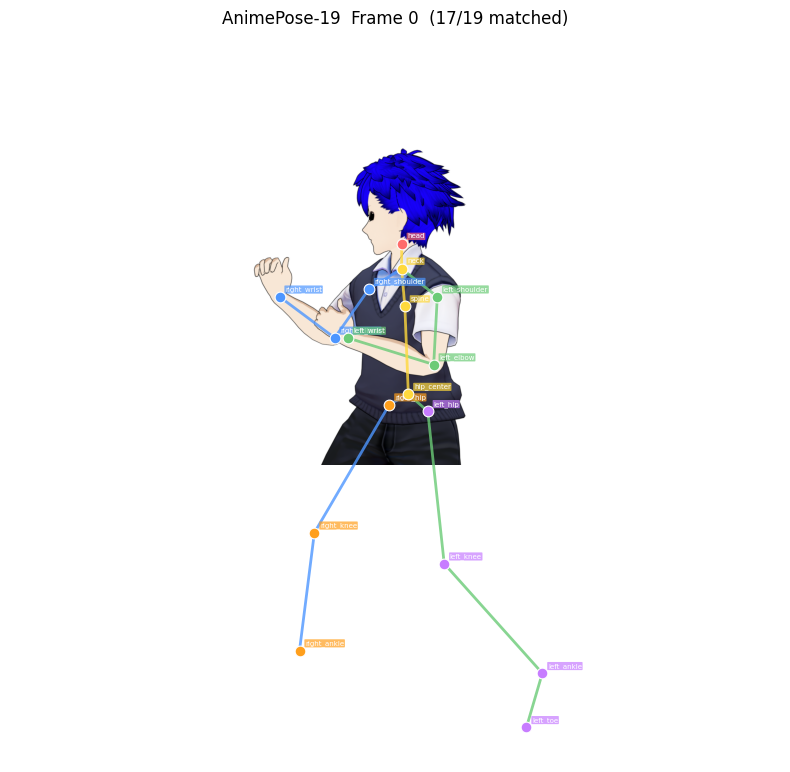

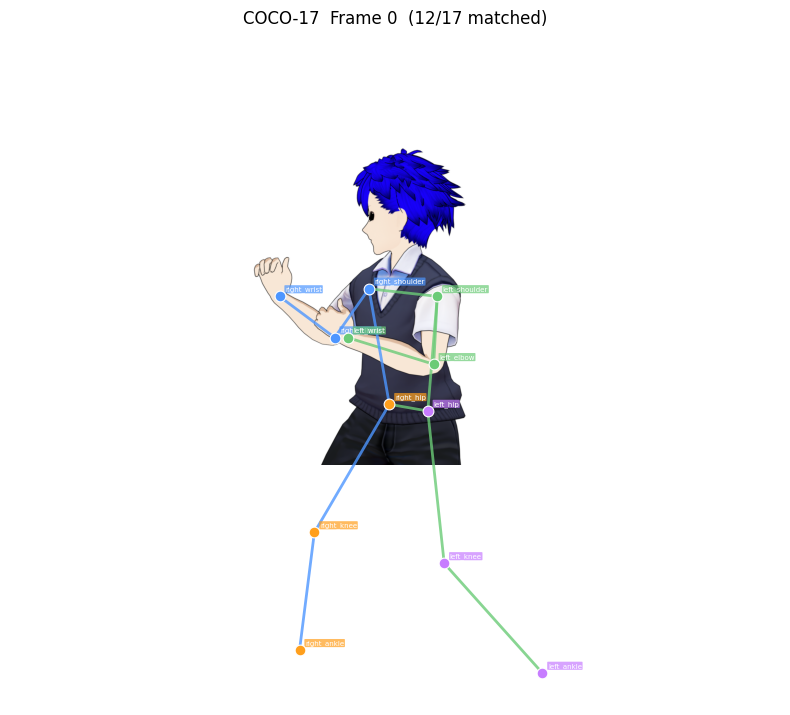

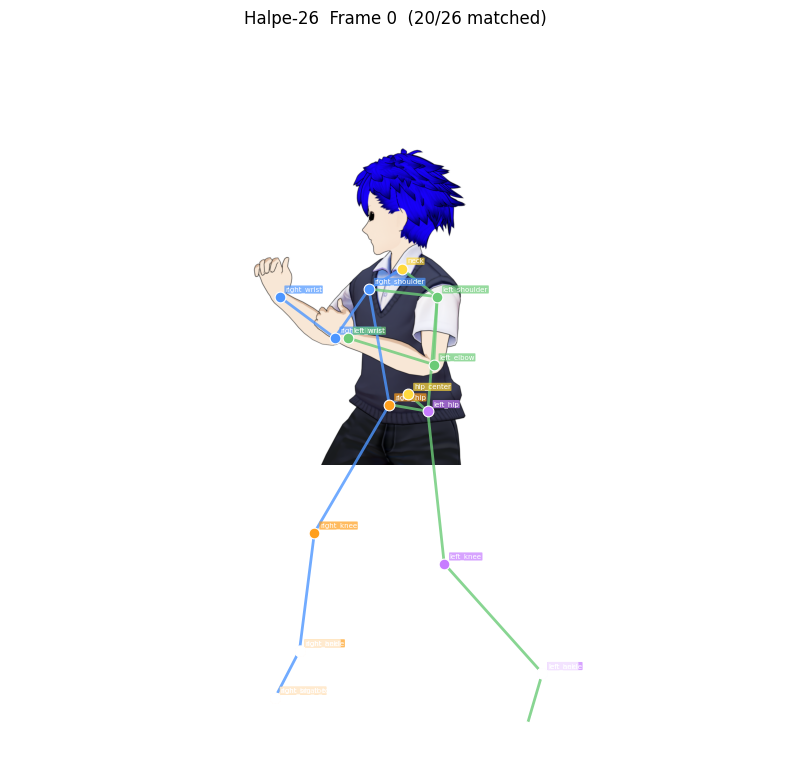

In [ ]:
def draw_standard_pose(frame_idx=0, fmt_name='AnimePose-19',
                        figsize=(8,14), point_size=60):
    """用指定标准格式在渲染帧上画骨架"""
    frame_kps  = frames_data[min(frame_idx, len(frames_data)-1)]
    img        = Image.open(img_files[min(frame_idx, len(img_files)-1)]).convert('RGB')
    fmt_map    = FORMAT_MAPS[fmt_name]
    skeleton   = FORMAT_SKELETONS[fmt_name]
    converted  = convert_frame(frame_kps, fmt_map)

    # 颜色方案
    KP_COLORS = {
        'head':'#FF6B6B','left_eye':'#FF6BCD','right_eye':'#FF6BCD',
        'neck':'#FFD93D','spine':'#FFD93D','hip_center':'#FFD93D',
        'left_shoulder':'#6BCB77','left_elbow':'#6BCB77','left_wrist':'#6BCB77',
        'right_shoulder':'#4D96FF','right_elbow':'#4D96FF','right_wrist':'#4D96FF',
        'left_hip':'#C77DFF','left_knee':'#C77DFF','left_ankle':'#C77DFF','left_toe':'#C77DFF',
        'right_hip':'#FF9F1C','right_knee':'#FF9F1C','right_ankle':'#FF9F1C','right_big_toe':'#FF9F1C',
    }
    LIMB_COLORS = {
        'left':'#6BCB77', 'right':'#4D96FF', 'center':'#FFD93D', 'other':'#FFFFFF'
    }
    def limb_color(a, b):
        if 'left' in a or 'left' in b: return LIMB_COLORS['left']
        if 'right' in a or 'right' in b: return LIMB_COLORS['right']
        return LIMB_COLORS['center']

    fig, ax = plt.subplots(1,1,figsize=figsize)
    ax.imshow(img)
    hit = sum(1 for v in converted.values() if v)
    ax.set_title(f"{fmt_name}  Frame {frame_idx}  ({hit}/{len(converted)} matched)", fontsize=12)

    # 骨架线
    for a, b in skeleton:
        pa = converted.get(a)
        pb = converted.get(b)
        if pa and pb:
            ax.plot([pa[0], pb[0]], [pa[1], pb[1]],
                    color=limb_color(a,b), linewidth=2, alpha=0.8, zorder=3)

    # 关键点
    for kp_name, coord in converted.items():
        if coord is None:
            continue
        c = KP_COLORS.get(kp_name, '#FFFFFF')
        ax.scatter(coord[0], coord[1], s=point_size, c=c, zorder=6,
                   linewidths=0.8, edgecolors='white')
        ax.annotate(kp_name, coord, fontsize=5, color='white',
                    xytext=(4,4), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.1', fc=c, alpha=0.7, lw=0))

    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 依次预览三种格式
for fmt in ['AnimePose-19', 'COCO-17', 'Halpe-26']:
    draw_standard_pose(frame_idx=FRAME_IDX, fmt_name=fmt)

/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 24335 (\N{CJK UNIFIED IDEOGRAPH-5F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_730292/4052619920.py:35: UserWarning: Glyph 23545 (\N{CJK UNIFIED I

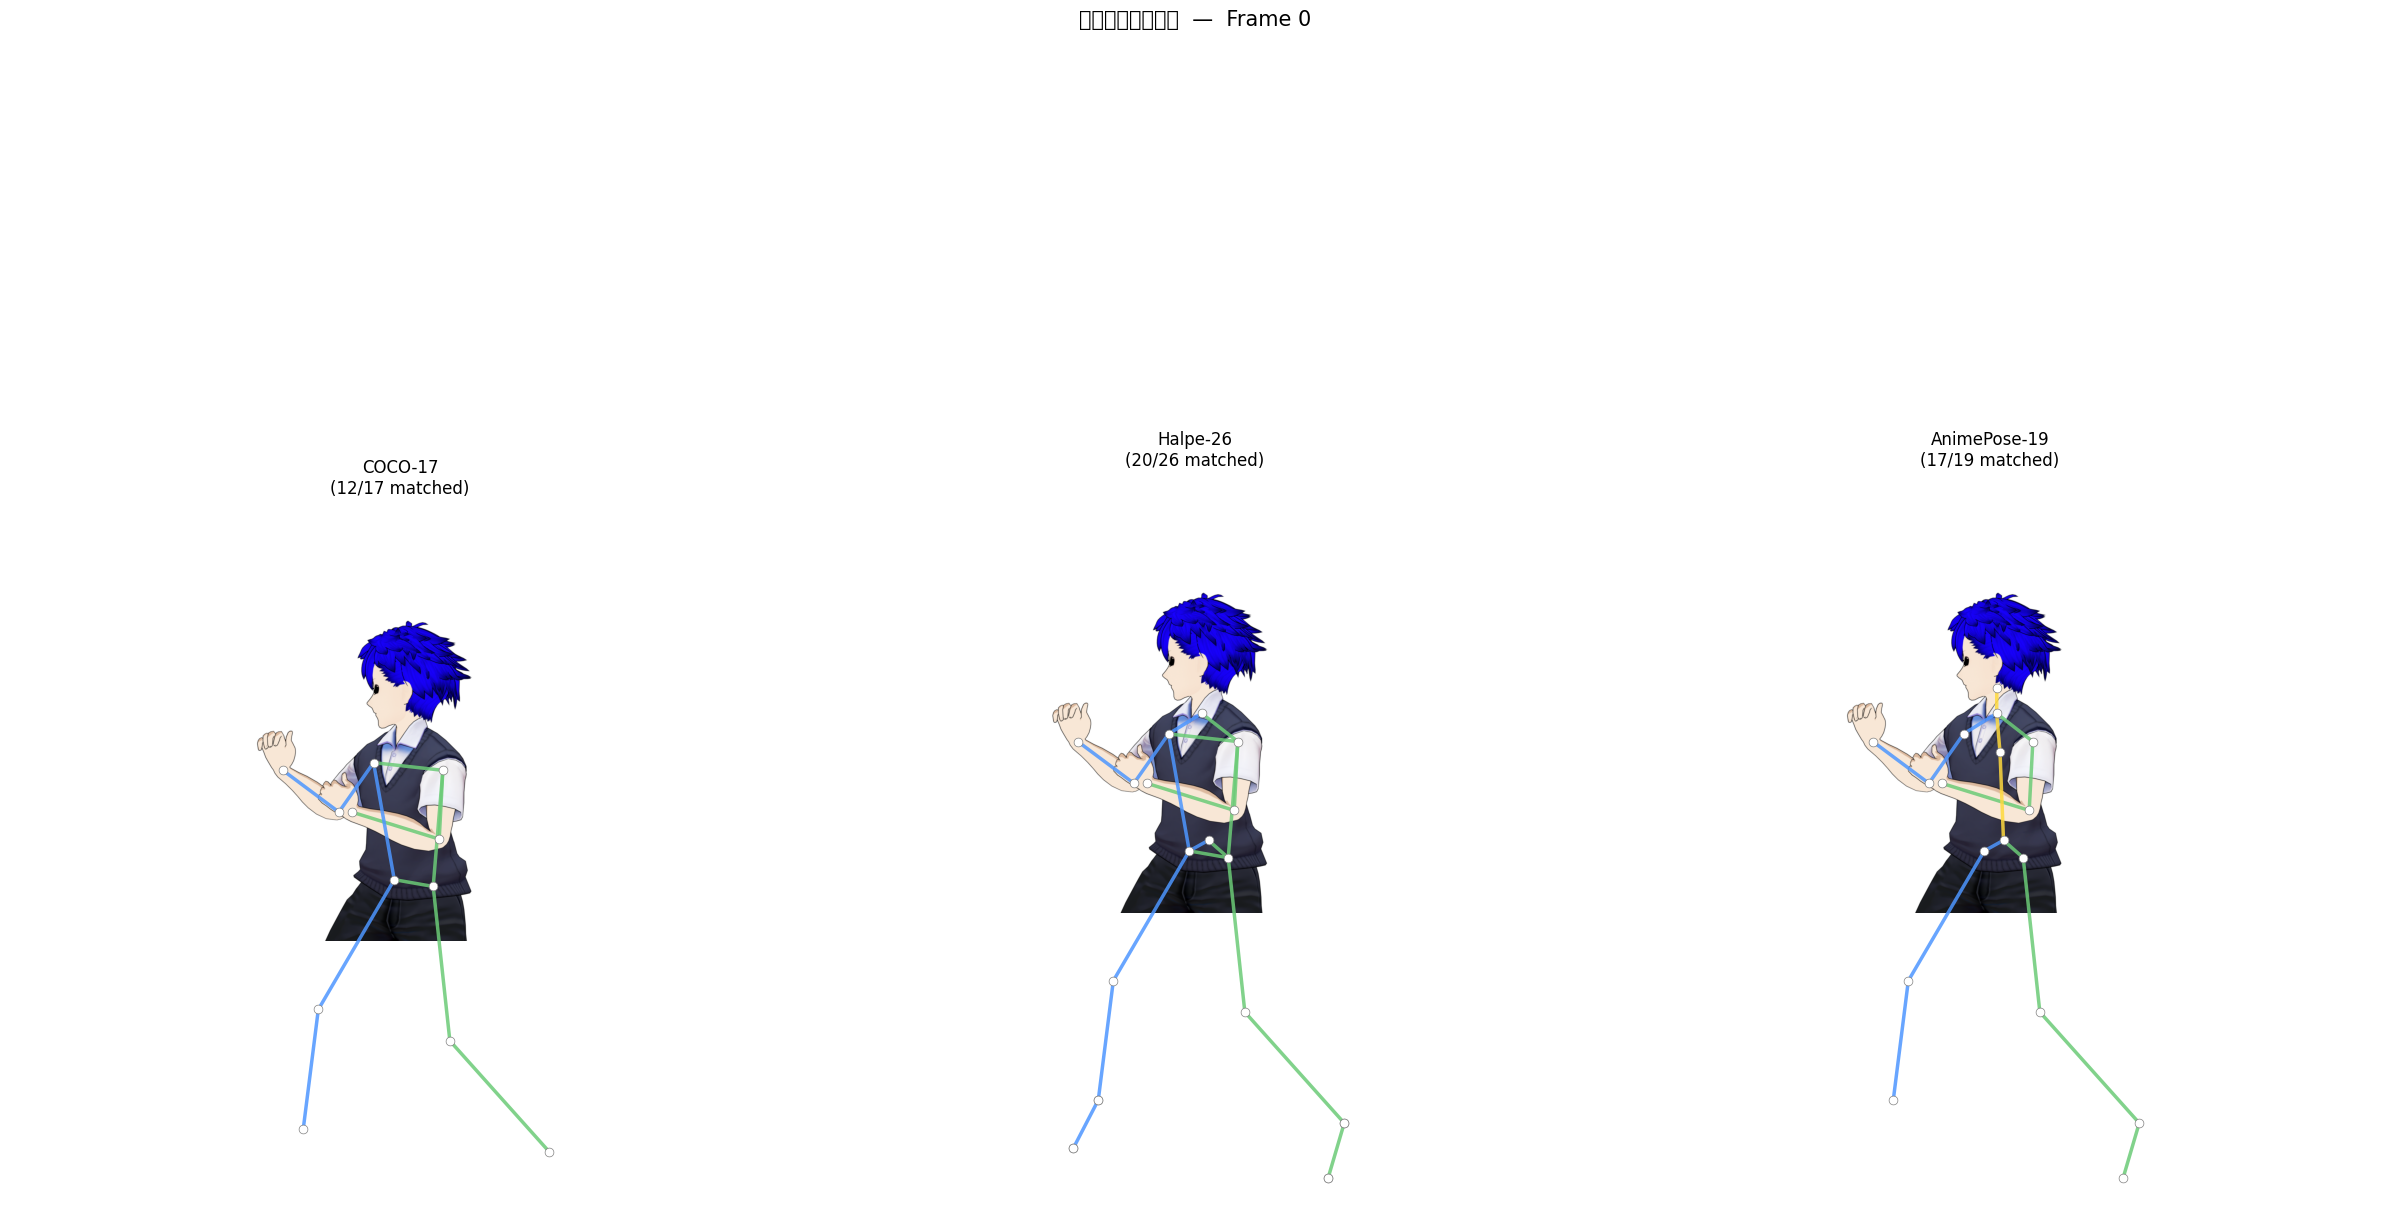

In [15]:
# ── 三格式并排对比（单帧）───────────────────────────────────────
fmts = ['COCO-17', 'Halpe-26', 'AnimePose-19']
fig, axes = plt.subplots(1, 3, figsize=(24, 16))
frame_idx = FRAME_IDX
frame_kps = frames_data[min(frame_idx, len(frames_data)-1)]
img = Image.open(img_files[min(frame_idx, len(img_files)-1)]).convert('RGB')

LIMB_LEFT  = '#6BCB77'
LIMB_RIGHT = '#4D96FF'
LIMB_MID   = '#FFD93D'

def quick_limb_color(a, b):
    if 'left' in a or 'left' in b:  return LIMB_LEFT
    if 'right' in a or 'right' in b: return LIMB_RIGHT
    return LIMB_MID

for ax, fmt_name in zip(axes, fmts):
    converted = convert_frame(frame_kps, FORMAT_MAPS[fmt_name])
    skeleton  = FORMAT_SKELETONS[fmt_name]
    ax.imshow(img)
    hit = sum(1 for v in converted.values() if v)
    ax.set_title(f"{fmt_name}\n({hit}/{len(converted)} matched)", fontsize=12)
    for a, b in skeleton:
        pa, pb = converted.get(a), converted.get(b)
        if pa and pb:
            ax.plot([pa[0],pb[0]],[pa[1],pb[1]],
                    color=quick_limb_color(a,b), lw=2.5, alpha=0.85, zorder=3)
    for kp_name, coord in converted.items():
        if coord:
            ax.scatter(coord[0], coord[1], s=40, c='white', zorder=6,
                       linewidths=0.5, edgecolors='gray')
    ax.axis('off')

plt.suptitle(f"三种标准格式对比  —  Frame {frame_idx}", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── 导出为 COCO-style JSON（可直接用于训练）───────────────────────
import json

def export_coco_style(fmt_name='AnimePose-19', out_path='output_keypoints.json'):
    fmt_map = FORMAT_MAPS[fmt_name]
    kp_names = [name for name, _ in fmt_map]
    annotations = []

    for fidx, (frame_kps, img_path) in enumerate(zip(frames_data, img_files)):
        converted = convert_frame(frame_kps, fmt_map)
        kps_flat = []
        for kp_name in kp_names:
            coord = converted.get(kp_name)
            if coord:
                kps_flat += [round(coord[0],2), round(coord[1],2), 2]  # v=2: visible
            else:
                kps_flat += [0.0, 0.0, 0]                               # v=0: missing
        annotations.append({
            "id":           fidx,
            "image_id":     fidx,
            "file_name":    os.path.basename(img_path),
            "keypoints":    kps_flat,
            "num_keypoints":sum(1 for i in range(2,len(kps_flat),3) if kps_flat[i]>0),
        })

    output = {
        "info": {"format": fmt_name, "source": "LinkTo-Anime"},
        "categories": [{"id":1, "name":"person", "keypoints": kp_names,
                         "skeleton": [[kp_names.index(a)+1, kp_names.index(b)+1]
                                      for a,b in FORMAT_SKELETONS[fmt_name]
                                      if a in kp_names and b in kp_names]}],
        "annotations": annotations,
    }
    with open(out_path, 'w') as f:
        json.dump(output, f, indent=2)
    print(f"已导出 {len(annotations)} 帧 → {out_path}")

# 示例：导出 AnimePose-19 格式
export_coco_style('AnimePose-19', 'anime19_keypoints.json')
export_coco_style('COCO-17',      'coco17_keypoints.json')

已导出 72 帧 → anime19_keypoints.json
已导出 72 帧 → coco17_keypoints.json
